In [11]:
# =============================================================================
# Notebook: O*NET Skills & Abilities — polar geometry analysis (paper-ready)
# =============================================================================
# Structure:
#   Cell 0  Setup
#   Cell 1  Compute overlays for Skills + Abilities
#   Cell 2  Build continuous angular profiles
#   Cell 3  Cluster profiles (paper Figure 2 inputs + clusters)
#   Cell 4  Paper figures: Figure 2 (profiles over bands) and Figure 3 (compass)
#   Cell 5  Test 1: angular neighbourhood -> HC similarity
#   Cell 6  Test 2: radial position -> HC concentration
#   Cell 7  (optional) Validation: k-means agreement vs profile clusters
# =============================================================================


# === Cell 0: Setup ===========================================================
import importlib

import numpy as np
import pandas as pd

import infra
import embeddings
import overlays
import profiles
import hc_analysis

importlib.reload(infra)
importlib.reload(embeddings)
importlib.reload(overlays)
importlib.reload(profiles)
importlib.reload(hc_analysis)

# Activate latest run + load config (strict: errors if none)
infra.activate_last_run(echo=False)
RP, cfg, ENCODER_SPEC = infra.load_embeddings_run(strict=True)

SEED = 42
np.random.seed(SEED)

YEAR = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_0"))
ENCODER_NAME = str(cfg.get("encoder_name", "")).strip()

print("PROJECT_ROOT :", infra.PROJECT_ROOT)
print("RUN_TAG      :", infra.RUN_TAG)
print("RUN_DIR      :", infra.RUN_DIR)
print("Exports      :", RP.exports)
print("Figures      :", RP.figures)
print("YEAR         :", YEAR)
print("ONET_VERSION :", ONET_VERSION)
print("ENCODER_NAME :", ENCODER_NAME)

PROJECT_ROOT : /home/joc/code/geometry-of-work
RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
Exports      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
Figures      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures
YEAR         : 2025
ONET_VERSION : 30_1
ENCODER_NAME : openai-3-large


In [12]:
# === Cell 1: Compute overlays for Skills + Abilities =========================
import onet
from infra import log

db = onet.get_db(version=ONET_VERSION)
log("O*NET version:", db.version)

# Load occupation embeddings (polar coordinates) from active run
df_occ = infra.read_csv_any(RP.export_fp("occupation_embeddings_polar_scaled.csv"))
log("Loaded df_occ:", df_occ.shape)

occ_geom = overlays.prepare_occ_geometry(df_occ)

skills_overlay = overlays.compute_overlay(
    db=db, df_occ=df_occ, table_basename="Skills", label="skill", occ_geom=occ_geom,
)
abilities_overlay = overlays.compute_overlay(
    db=db, df_occ=df_occ, table_basename="Abilities", label="ability", occ_geom=occ_geom,
)


• O*NET version: 30.1
• Loaded df_occ: (878, 13)
• Overlay: Skills (LV) → 35 descriptors
• Overlay: Abilities (LV) → 52 descriptors


In [13]:
# === Cell 2: Build continuous angular profiles ===============================
skills_profiles = profiles.build_continuous_profiles(skills_overlay)
abilities_profiles = profiles.build_continuous_profiles(abilities_overlay)

log("Skills profiles:   ", skills_profiles.P.shape)
log("Abilities profiles:", abilities_profiles.P.shape)

• Skills profiles:    (35, 720)
• Abilities profiles: (52, 720)


In [14]:
# === Cell 3: Cluster profiles ================================================
skills_clusters = profiles.cluster_profiles(skills_profiles)
abilities_clusters = profiles.cluster_profiles(abilities_profiles)

print("\n=== Skill clusters ===")
print(skills_clusters.cluster_meta.to_string(index=False))
print("\n=== Ability clusters ===")
print(abilities_clusters.cluster_meta.to_string(index=False))

• [skill] selected K=2  ARI_mean=1.000  std=0.000  frag=1.60
• [ability] selected K=2  ARI_mean=0.938  std=0.124  frag=4.00

=== Skill clusters ===
 cluster  center_median  n  band_mean  band_p90  band_max  cluster_rank
       0       0.721997 27   0.337732  0.441324  0.463324             1
       1       0.264205  8   0.251529  0.344132  0.370455             2

=== Ability clusters ===
 cluster  center_median  n  band_mean  band_p90  band_max  cluster_rank
       0       0.787697 20   0.209579  0.278316  0.299635             1
       1       0.318779 32   0.372731  0.407513  0.430695             2


• Saved figure: skills_profiles_over_bands__all__value_norm01_global.pdf


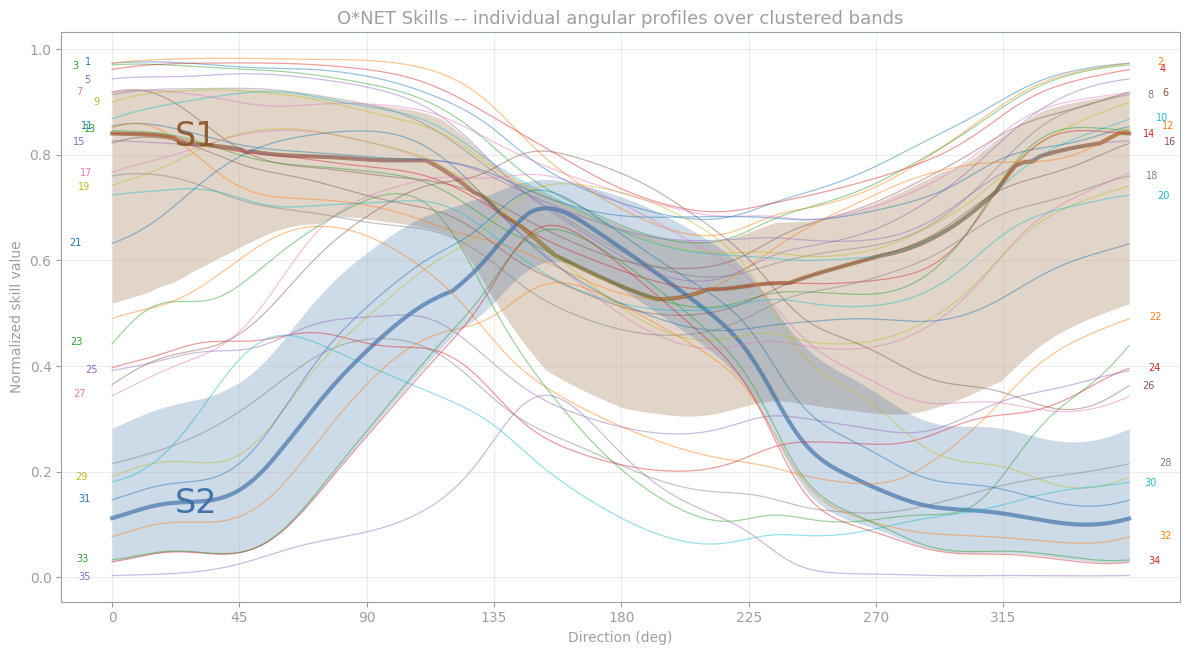

• Saved figure: abilitys_profiles_over_bands__all__value_norm01_global.pdf


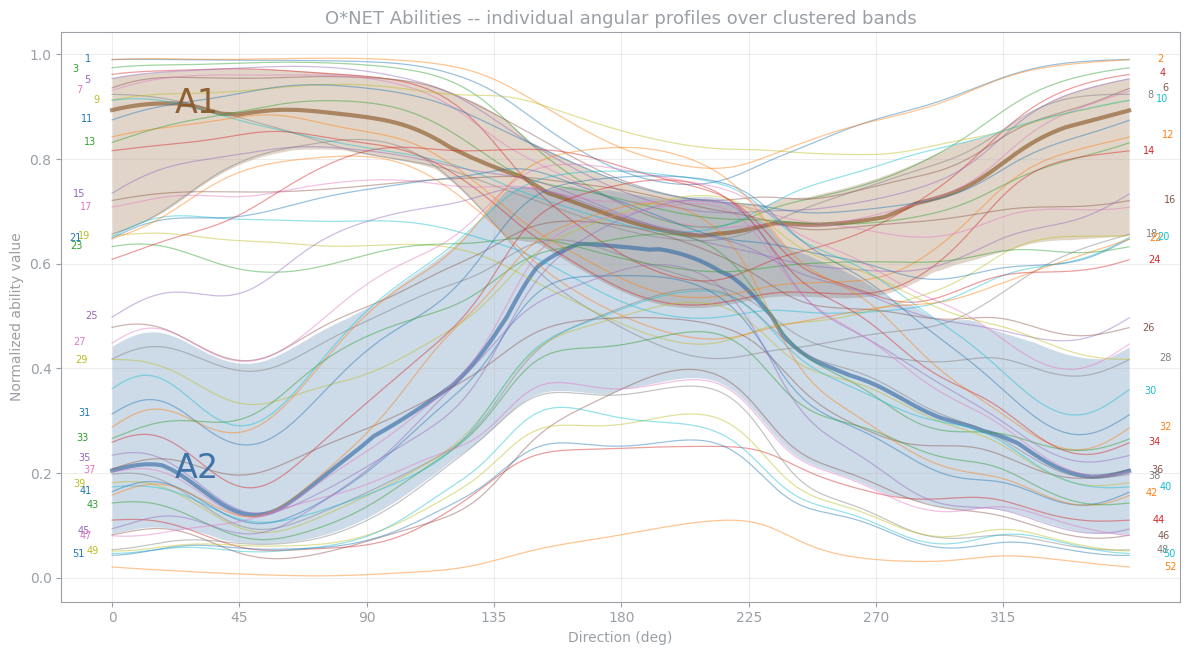

• Saved compass membership: gradient_compass_clusters_membership.csv
• Saved figure: master_gradient_compass_4clusters.pdf


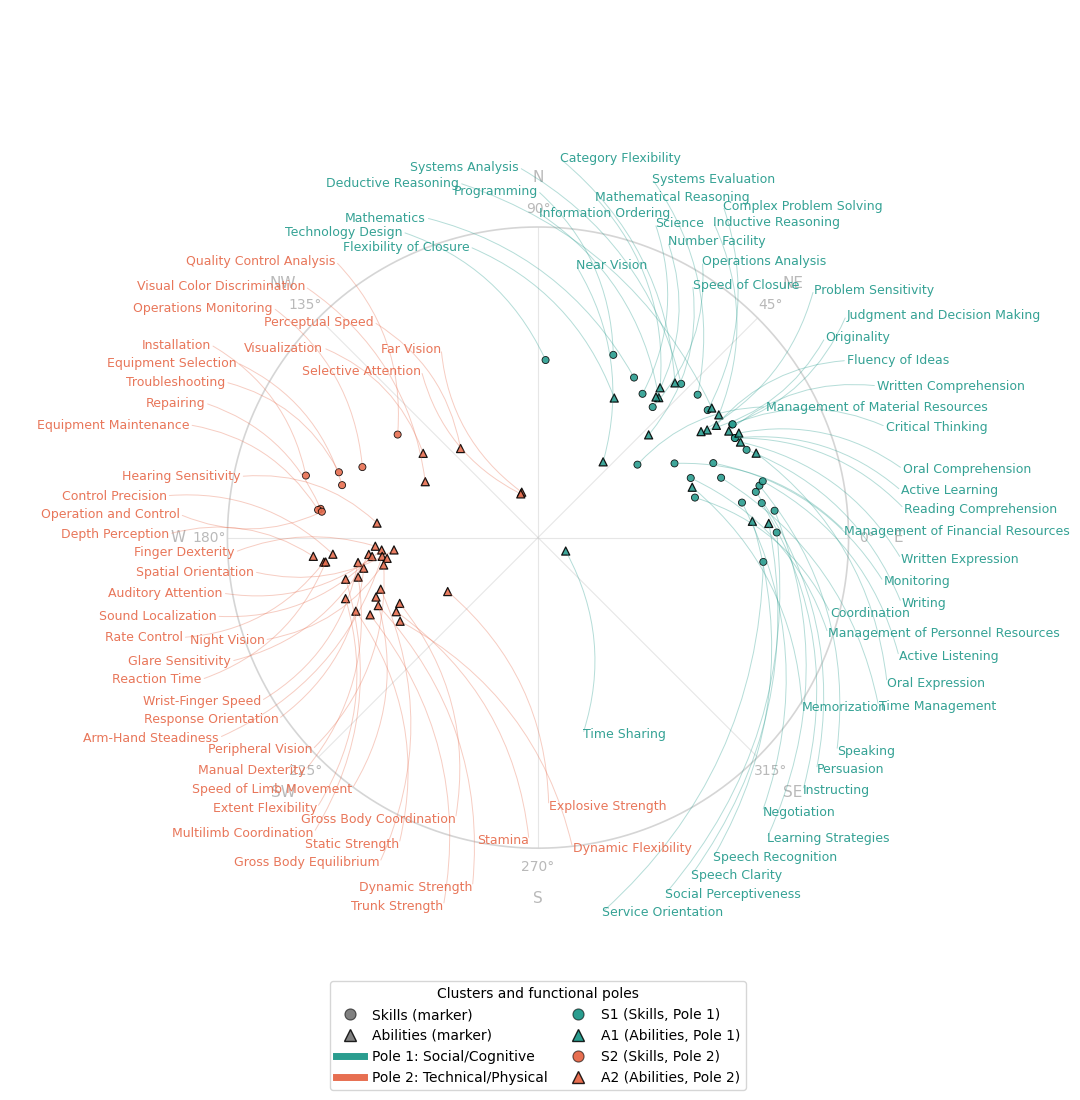

{'pdf': PosixPath('/home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/master_gradient_compass_4clusters.pdf'),
 'png': PosixPath('/home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/master_gradient_compass_4clusters.png'),
 'membership': PosixPath('/home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/gradient_compass_clusters_membership.csv')}

In [15]:
# === Cell 4: Paper figures ===================================================
# Figure 2 (top panel — Skills, bottom panel — Abilities; saved as two files)
profiles.plot_profiles_over_bands(skills_profiles, skills_clusters)
profiles.plot_profiles_over_bands(abilities_profiles, abilities_clusters)

# Figure 3
profiles.plot_gradient_compass(
    skills_overlay=skills_overlay,
    abilities_overlay=abilities_overlay,
    skills_clusters=skills_clusters,
    abilities_clusters=abilities_clusters,
)

• [Test 1] skills: 878 occs, 385003 pairs, 30 bins
• [Test 1] abilitys: 878 occs, 385003 pairs, 30 bins
• Saved figure: hc_test1__angular_similarity.pdf


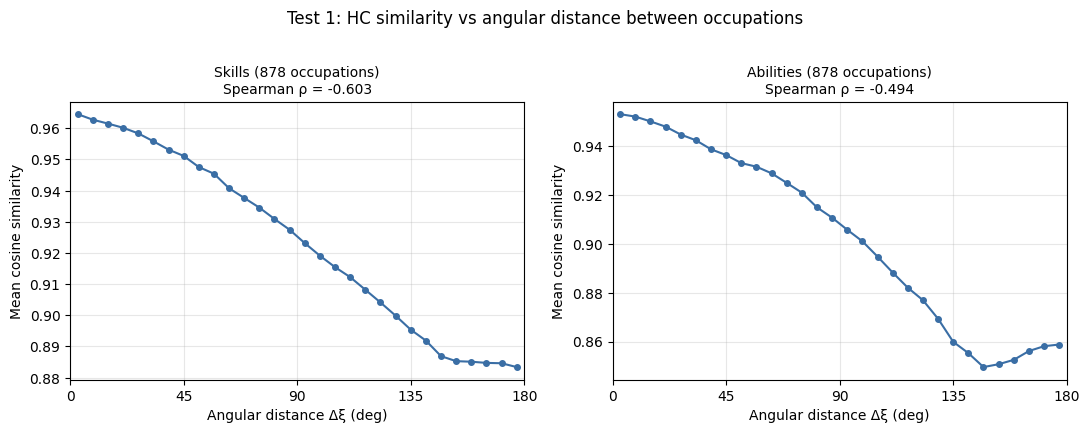

{'pdf': PosixPath('/home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/hc_test1__angular_similarity.pdf'),
 'png': PosixPath('/home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/hc_test1__angular_similarity.png')}

In [16]:
# === Cell 5: Test 1 — angular HC similarity ==================================
import importlib
import hc_analysis
importlib.reload(hc_analysis)

test1_skills = hc_analysis.compute_angular_similarity(skills_overlay)
test1_abilities = hc_analysis.compute_angular_similarity(abilities_overlay)

hc_analysis.plot_test1_angular_similarity(test1_skills, test1_abilities)

• [Angular variance] skills: median R²(ξ)=0.546, R²(χ)=0.007
• [Angular variance] abilitys: median R²(ξ)=0.424, R²(χ)=0.008

=== Angular variance decomposition ===
Skills    (35 descriptors):
  median_R2_xi                             0.546
  median_R2_chi_of_total                   0.007
  median_R2_residual                       0.437
  frac_descriptors_R2_xi_above_0.3         0.886
  frac_descriptors_R2_xi_above_0.5         0.571
Abilities (52 descriptors):
  median_R2_xi                             0.424
  median_R2_chi_of_total                   0.008
  median_R2_residual                       0.556
  frac_descriptors_R2_xi_above_0.3         0.788
  frac_descriptors_R2_xi_above_0.5         0.250
• Saved figure: radial_spec__angular_variance.pdf


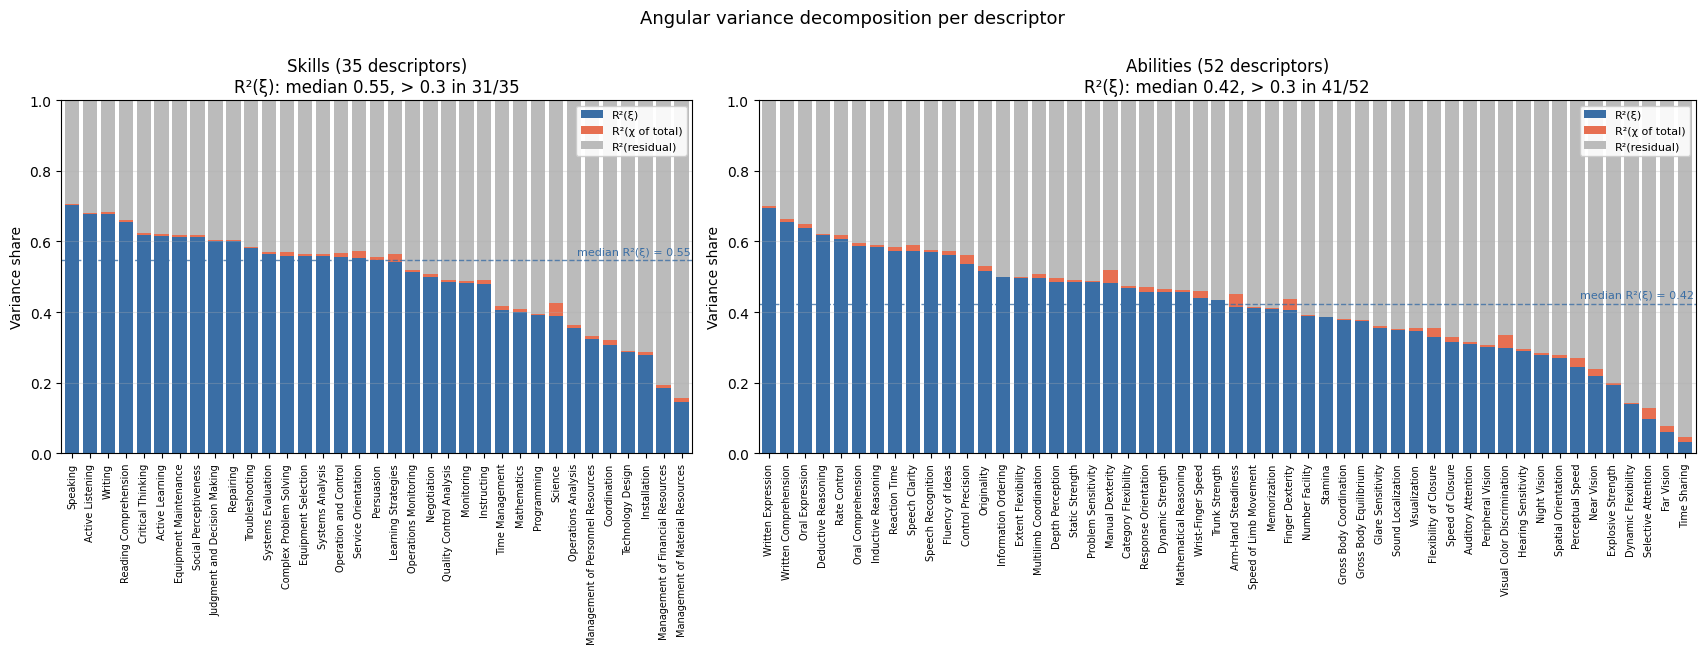

{'pdf': PosixPath('/home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/radial_spec__angular_variance.pdf'),
 'png': PosixPath('/home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/radial_spec__angular_variance.png')}

In [17]:
# === Cell 6: Angular variance decomposition =================================
# Quantifies how much of each descriptor's variance is explained by xi vs chi.
# Paper claim: xi carries most of the structure; chi adds a small additional
# component after xi-residualization.

import radial_specialization
importlib.reload(radial_specialization)

ang_skills = radial_specialization.compute_angular_variance(skills_overlay)
ang_abilities = radial_specialization.compute_angular_variance(abilities_overlay)

print("\n=== Angular variance decomposition ===")
print(f"Skills    ({ang_skills.summary['n_descriptors']} descriptors):")
for k, v in ang_skills.summary.items():
    if k != "n_descriptors":
        print(f"  {k:<40} {v:.3f}")
print(f"Abilities ({ang_abilities.summary['n_descriptors']} descriptors):")
for k, v in ang_abilities.summary.items():
    if k != "n_descriptors":
        print(f"  {k:<40} {v:.3f}")

radial_specialization.plot_angular_variance(ang_skills, ang_abilities)


• [Radial intensification] skills: norm_v_minus_global partial ρ=+0.495
• [Radial intensification] abilitys: norm_v_minus_global partial ρ=+0.281

=== Radial intensification — statistics ===

Skills:
                 metric                      display_name  rho_global  p_global  n_global  rho_partial_xi  p_partial_xi  n_partial  frac_sectors_positive  median_sector_rho  n_sectors
    norm_v_minus_global Distance from global mean profile      +0.503    +0.000       878          +0.495        +0.000        878                 +1.000             +0.510     +8.000
         gini_resid_abs                Gini on |residual|      +0.042    +0.213       878          +0.032        +0.350        878                 +0.375             -0.013     +8.000
participation_resid_abs       Participation on |residual|      -0.049    +0.144       878          -0.037        +0.279        878                 +0.500             +0.012     +8.000

Abilities:
                 metric                      display

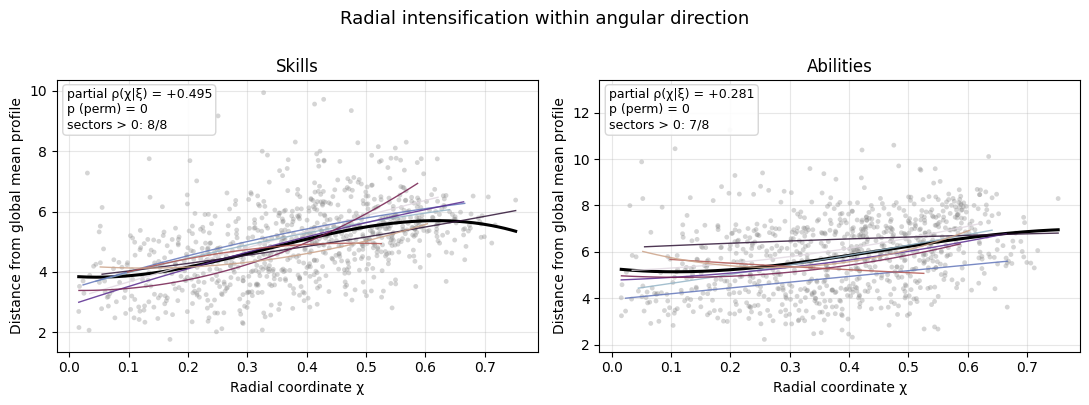

{'pdf': PosixPath('/home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/radial_spec__intensification.pdf'),
 'png': PosixPath('/home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/radial_spec__intensification.png')}

In [18]:
# === Cell 7: Radial intensification within direction =========================
# Tests three operationalizations of "specialization within direction":
#   (i)   intensification — distance from global mean profile (POSITIVE result)
#   (ii)  Gini on |residual| (NULL result)
#   (iii) Participation on |residual| (NULL result)
# Statistics: global Spearman, partial Spearman vs xi (permutation p-value),
# and per-sector consistency over 8 sectors.

rad_skills = radial_specialization.compute_radial_intensification(
    skills_overlay, n_permutations=1000,
)
rad_abilities = radial_specialization.compute_radial_intensification(
    abilities_overlay, n_permutations=1000,
)

print("\n=== Radial intensification — statistics ===")
print("\nSkills:")
print(rad_skills.statistics_df.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))
print("\nAbilities:")
print(rad_abilities.statistics_df.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

radial_specialization.plot_radial_intensification(rad_skills, rad_abilities)

In [19]:
# === Cell 8: Skills/Abilities summary table ==================================
# Combines headline numbers from Test 1, angular variance, and radial
# intensification into a single table. Writes CSV + LaTeX, and prints
# a formatted version to the notebook.

import importlib
import skillabil_summary
importlib.reload(skillabil_summary)

summary_df = skillabil_summary.build_summary_table(
    test1_skills=test1_skills,
    test1_abilities=test1_abilities,
    ang_skills=ang_skills,
    ang_abilities=ang_abilities,
    rad_skills=rad_skills,
    rad_abilities=rad_abilities,
)

• Saved CSV:   skillabil_summary.csv
• Saved LaTeX: skillabil_summary.tex

────────────────────────────────────────────────────────────
Statistic                              Skills  Abilities
────────────────────────────────────────────────────────────

Test 1 — angular variation
  Spearman ρ (HC similarity vs Δξ)  -0.603***  -0.494***

Angular variance decomposition
  Median R²(ξ)                           0.55       0.42
  Median R²(χ)                          0.007      0.008

Test 2 — radial intensification
  Partial Spearman ρ(χ|ξ)           +0.495***  +0.281***
────────────────────────────────────────────────────────────
Significance: *** p<0.001  ** p<0.01  * p<0.05 (permutation test)



In [20]:
# === Cell 9 (OPTIONAL): Validation — k-means agreement vs profile clusters ===
# Algorithmic sanity check: weighted k-means on the unit circle (theta_max
# weighted by R) should largely agree with the profile-derived clustering.
# This cell is for validation only; not used in the paper.

def _validation_kmeans_agreement():
    import numpy as np
    import pandas as pd

    def _wrap_deg(d): return float(d) % 360.0

    def _unit_xy(theta_deg):
        th = np.deg2rad(theta_deg)
        return np.cos(th), np.sin(th)

    def weighted_kmeans(X, w=None, k=2, n_init=20, max_iter=200, tol=1e-7, seed=0):
        rng = np.random.default_rng(seed)
        X = np.asarray(X, float)
        n = X.shape[0]
        w = np.ones(n) if w is None else np.asarray(w, float)
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
        best_inertia = np.inf
        best = None

        def init_centers():
            centers = np.empty((k, 2))
            p = w / (w.sum() + 1e-12)
            i0 = rng.choice(n, p=p)
            centers[0] = X[i0]
            for j in range(1, k):
                d2 = np.min(((X[:, None, :] - centers[None, :j, :]) ** 2).sum(axis=2), axis=1)
                q = w * d2
                ij = rng.choice(n, p=q / q.sum()) if q.sum() > 0 else rng.integers(0, n)
                centers[j] = X[ij]
            return centers

        for _ in range(n_init):
            centers = init_centers()
            for _ in range(max_iter):
                d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
                labels = np.argmin(d2, axis=1)
                new_centers = centers.copy()
                for j in range(k):
                    m = labels == j
                    ww = w[m]
                    if ww.sum() > 0:
                        new_centers[j] = (X[m] * ww[:, None]).sum(axis=0) / ww.sum()
                    else:
                        new_centers[j] = X[rng.integers(0, n)]
                if np.max(np.abs(new_centers - centers)) < tol:
                    centers = new_centers
                    break
                centers = new_centers
            d2 = ((X - centers[labels]) ** 2).sum(axis=1)
            inertia = (w * d2).sum()
            if inertia < best_inertia:
                best_inertia = inertia
                best = (labels.copy(), centers.copy())
        return best[0], best[1]

    def map_majority(d, algo_col, target_labels):
        scores = {(cl, tl): float(d.loc[(d[algo_col] == cl) & (d["rank"] == tl), "R"].sum())
                  for cl in sorted(d[algo_col].unique())
                  for tl in target_labels}
        mapping, used = {}, set()
        for cl in sorted(d[algo_col].unique()):
            cand = sorted(target_labels, key=lambda tl: scores[(cl, tl)], reverse=True)
            for tl in cand:
                if tl not in used:
                    mapping[cl] = tl; used.add(tl); break
        return mapping

    rows = []
    for overlay, cluster_res, type_name in [
        (skills_overlay, skills_clusters, "Skill"),
        (abilities_overlay, abilities_clusters, "Ability"),
    ]:
        df = overlay.angles_df.rename(columns={overlay.label: "name"}).copy()
        df["theta_max_deg"] = df["theta_max_deg"].map(_wrap_deg)
        df["R"] = df["resultant_R"]
        rank_map = cluster_res.members_df.set_index("name")["cluster_rank"].to_dict()
        df["rank"] = df["name"].map(rank_map)
        df = df.dropna(subset=["rank"]).copy()
        df["rank"] = df["rank"].astype(int)
        df["type"] = type_name

        xy = np.array([_unit_xy(t) for t in df["theta_max_deg"]])
        df["ux"], df["uy"] = xy[:, 0], xy[:, 1]
        labs, _ = weighted_kmeans(df[["ux", "uy"]].to_numpy(), w=df["R"].to_numpy(), k=2, seed=1)
        df["kmeans2"] = labs
        target_labels = sorted(df["rank"].unique().tolist())[:2]
        mapping = map_majority(df, "kmeans2", target_labels)
        df["kmeans_rank"] = df["kmeans2"].map(mapping)
        df["match"] = df["kmeans_rank"].eq(df["rank"])

        acc_unw = df["match"].mean()
        acc_w = (df["match"].astype(float) * df["R"]).sum() / df["R"].sum()
        print(f"\n[{type_name}] kmeans agreement vs profile-derived clusters:")
        print(f"  unweighted: {acc_unw*100:.1f}%   weighted (R): {acc_w*100:.1f}%")
        print(pd.crosstab(df["rank"], df["kmeans_rank"], margins=True))
        rows.append(df)

    out = pd.concat(rows, ignore_index=True)
    out.to_csv(infra.RP.export_fp("validation__kmeans_vs_profile_clusters.csv"), index=False)

# Uncomment to run the validation:
_validation_kmeans_agreement()


[Skill] kmeans agreement vs profile-derived clusters:
  unweighted: 100.0%   weighted (R): 100.0%
kmeans_rank   1  2  All
rank                   
1            27  0   27
2             0  8    8
All          27  8   35

[Ability] kmeans agreement vs profile-derived clusters:
  unweighted: 98.1%   weighted (R): 99.5%
kmeans_rank   1   2  All
rank                    
1            20   0   20
2             1  31   32
All          21  31   52
